In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [3]:
import pandas as pd
import os

dataset_path = os.path.join(path, 'creditcard.csv')
df = pd.read_csv(dataset_path)

print(f"Shape of the dataset: {df.shape}")
display(df.head())

Shape of the dataset: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Class
0    284315
1       492
Name: count, dtype: int64

Fraud Percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


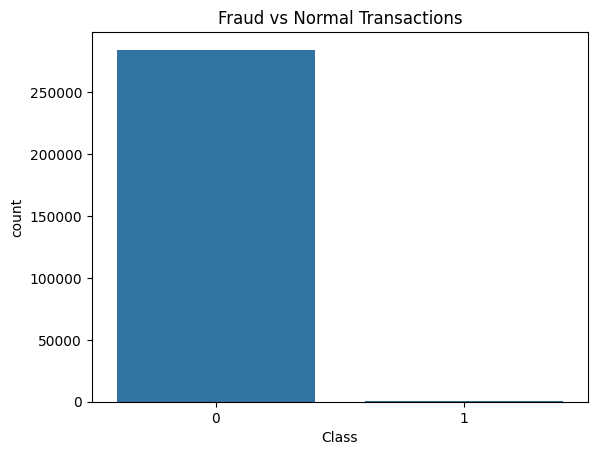

In [4]:
# fraud vs normal counts
print(df["Class"].value_counts())

fraud_percentage = df["Class"].value_counts(normalize=True) * 100
print("\nFraud Percentage:")
print(fraud_percentage)

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Class", data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

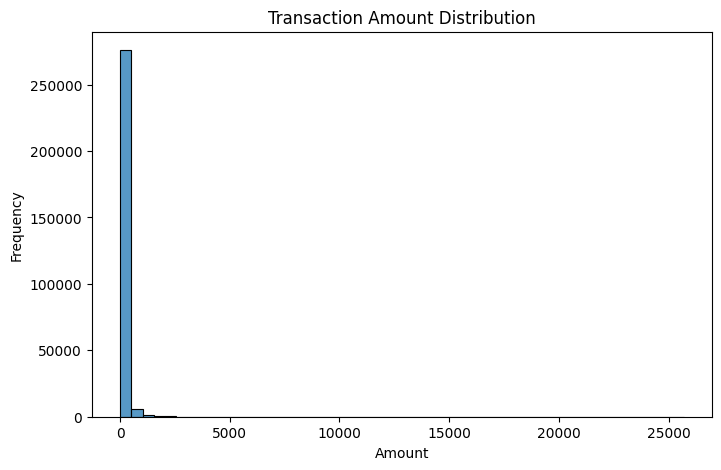

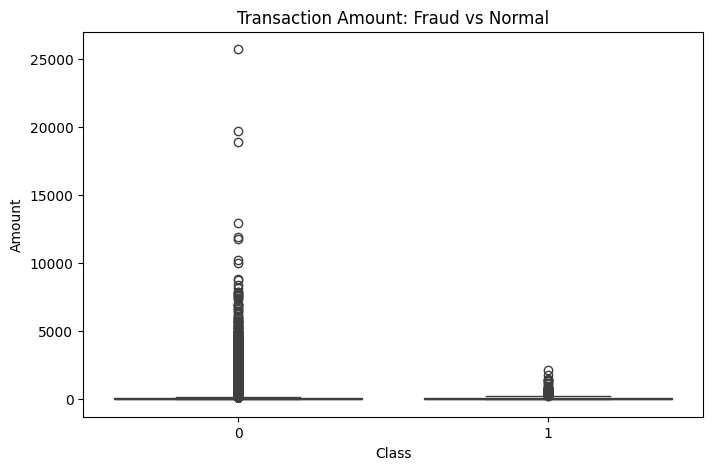

In [5]:
# Transaction amount distribution

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["Amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

# Fraud vs Normal Amount
plt.figure(figsize=(8,5))
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Transaction Amount: Fraud vs Normal")
plt.show()

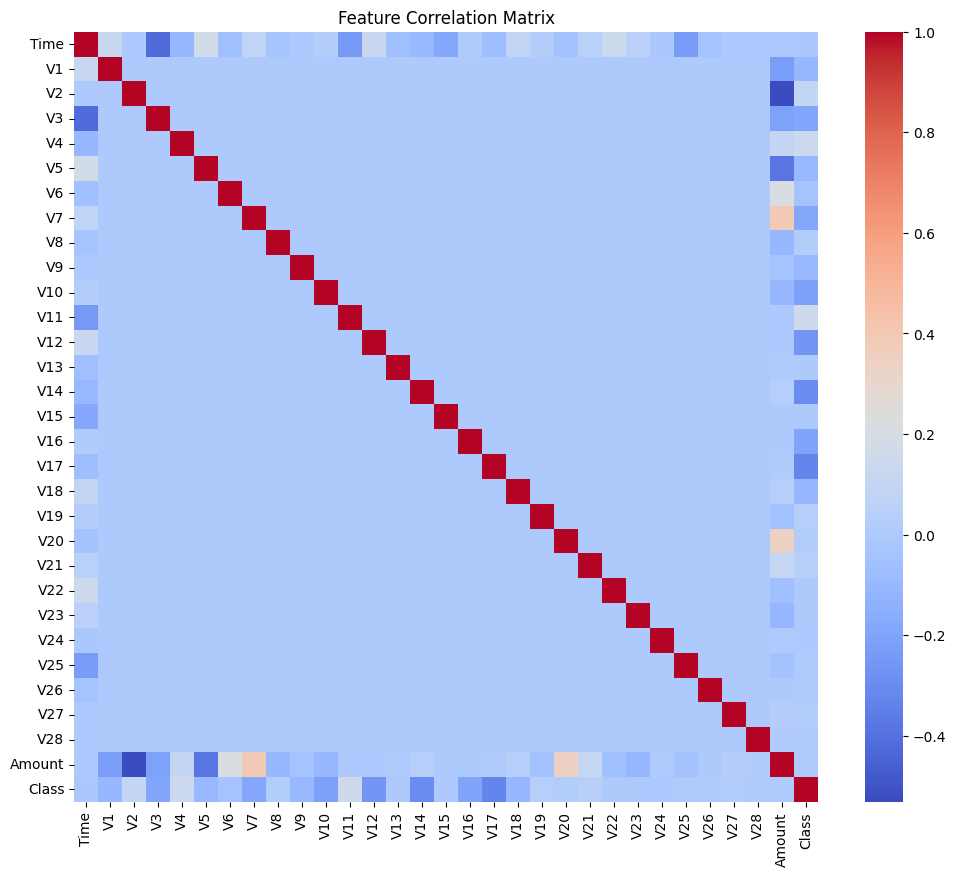

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [7]:
from sklearn.model_selection import train_test_split

# Assuming 'df' is already loaded from previous cells
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Shape of X (features):", X.shape)
print("Shape of y (target):", y.shape)
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)
print("Class distribution in y_train:\n", y_train.value_counts(normalize=True))
print("Class distribution in y_test:\n", y_test.value_counts(normalize=True))

Shape of X (features): (284807, 30)
Shape of y (target): (284807,)
Shape of X_train: (227845, 30)
Shape of X_test: (56962, 30)
Shape of y_train: (227845,)
Shape of y_test: (56962,)
Class distribution in y_train:
 Class
0    0.998271
1    0.001729
Name: proportion, dtype: float64
Class distribution in y_test:
 Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64


--- Logistic Regression ---
Logistic Regression Cross-Validation Results:
  fit_time: 4.9854 (+/- 0.2985)
  score_time: 0.1549 (+/- 0.0520)
  test_roc_auc: 0.9747 (+/- 0.0091)
  test_pr_auc: 0.7479 (+/- 0.0251)
  test_recall: 0.9086 (+/- 0.0065)
  test_precision: 0.0567 (+/- 0.0012)
  test_f1: 0.1067 (+/- 0.0022)

Logistic Regression Initial Evaluation (Default Threshold):
Confusion Matrix:
 [[55399  1465]
 [    8    90]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC AUC Score: 0.9708092455468401
Average Precision Score: 0.7225333909920981

Logistic Regression Evaluation (Tuned Threshold: 1.0000):
Confusion Matrix:
 [[56848    16]
 [   18    80]]
Classification Report:
             

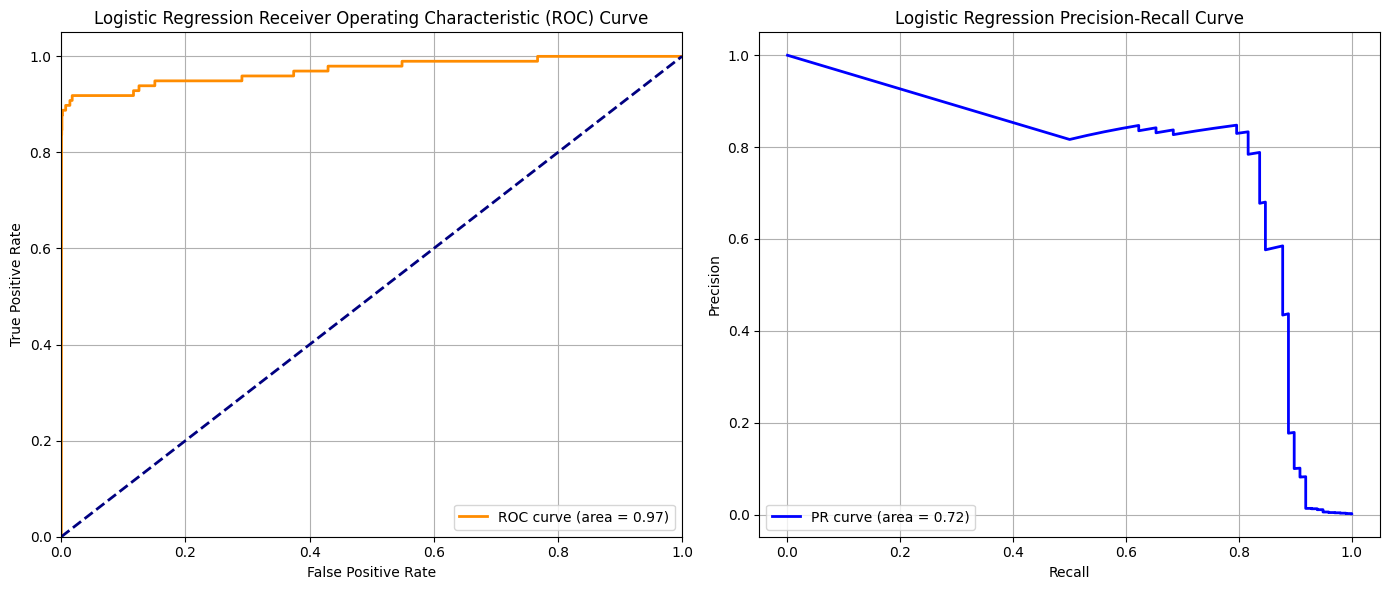

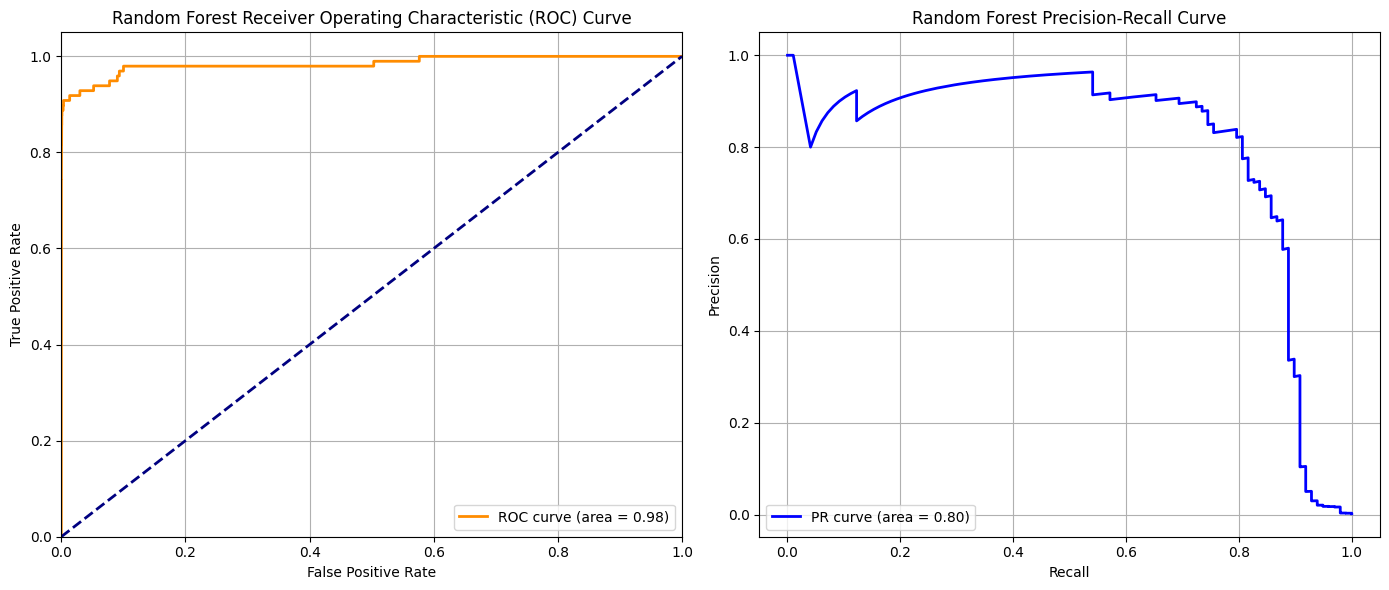

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, auc
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# 2. Define scoring dictionary
scoring = {
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision',
    'recall': 'recall',
    'precision': 'precision',
    'f1': 'f1'
}

# 3. Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42) # Reduced n_splits to 3

print("--- Logistic Regression ---")
# 4. For Logistic Regression:
# Create an imblearn.Pipeline
log_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced'))
])

# Perform cross-validation
print("Logistic Regression Cross-Validation Results:")
log_reg_cv_results = cross_validate(log_reg_pipeline, X_train, y_train, cv=skf, scoring=scoring, return_train_score=False, verbose=0)
for metric_name, values in log_reg_cv_results.items():
    print(f"  {metric_name}: {np.mean(values):.4f} (+/- {np.std(values):.4f})")

# Fit log_reg_pipeline
log_reg_pipeline.fit(X_train, y_train)

# Predict class labels and probabilities on X_test
y_pred_log_reg = log_reg_pipeline.predict(X_test)
y_prob_log_reg = log_reg_pipeline.predict_proba(X_test)[:, 1]

# Print initial evaluation metrics
print("\nLogistic Regression Initial Evaluation (Default Threshold):")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log_reg))
print("Classification Report:\n", classification_report(y_test, y_pred_log_reg))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob_log_reg))
print("Average Precision Score:", average_precision_score(y_test, y_prob_log_reg))

# Implement F1-score based threshold tuning for Logistic Regression
precision_lr, recall_lr, thresholds_lr = precision_recall_curve(y_test, y_prob_log_reg)
f1_scores_lr = 2 * (precision_lr * recall_lr) / (precision_lr + recall_lr)
f1_scores_lr = np.nan_to_num(f1_scores_lr)
best_threshold_lr = thresholds_lr[np.argmax(f1_scores_lr[:-1])]

y_pred_thr_log_reg = (y_prob_log_reg >= best_threshold_lr).astype(int)

print(f"\nLogistic Regression Evaluation (Tuned Threshold: {best_threshold_lr:.4f}):")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_thr_log_reg))
print("Classification Report:\n", classification_report(y_test, y_pred_thr_log_reg))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob_log_reg)) # ROC AUC is threshold-independent
print("Average Precision Score:", average_precision_score(y_test, y_prob_log_reg)) # PR AUC is threshold-independent

print("\n--- Random Forest Model ---")
# 5. For Random Forest Model:
# Create an imblearn.Pipeline
rf_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=12, min_samples_leaf=2, random_state=42, class_weight='balanced')) # Reduced n_estimators to 100
])

# Perform cross-validation
print("Random Forest Cross-Validation Results:")
rf_cv_results = cross_validate(rf_pipeline, X_train, y_train, cv=skf, scoring=scoring, return_train_score=False, verbose=0)
for metric_name, values in rf_cv_results.items():
    print(f"  {metric_name}: {np.mean(values):.4f} (+/- {np.std(values):.4f})")

# Fit rf_pipeline
rf_pipeline.fit(X_train, y_train)

# Predict class labels and probabilities on X_test
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

# Print initial evaluation metrics
print("\nRandom Forest Initial Evaluation (Default Threshold):")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob_rf))
print("Average Precision Score:", average_precision_score(y_test, y_prob_rf))

# Implement F1-score based threshold tuning for Random Forest
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, y_prob_rf)
f1_scores_rf = 2 * (precision_rf * recall_rf) / (precision_rf + recall_rf)
f1_scores_rf = np.nan_to_num(f1_scores_rf)
best_threshold_rf = thresholds_rf[np.argmax(f1_scores_rf[:-1])]

y_pred_thr_rf = (y_prob_rf >= best_threshold_rf).astype(int)

print(f"\nRandom Forest Evaluation (Tuned Threshold: {best_threshold_rf:.4f}):")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_thr_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_thr_rf))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob_rf))
print("Average Precision Score:", average_precision_score(y_test, y_prob_rf))

# 6. Visualization:
def plot_roc_pr(y_true, y_prob, model_name):
    # Calculate ROC curve components and AUC
    fpr, tpr, roc_thresholds = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    # Calculate Precision-Recall curve components and PR AUC
    precision, recall, pr_thresholds = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)

    plt.figure(figsize=(14, 6))

    # Plot ROC curve
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(True)

    # Plot Precision-Recall curve
    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (area = {pr_auc:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{model_name} Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Call plot_roc_pr for Logistic Regression
plot_roc_pr(y_test, y_prob_log_reg, 'Logistic Regression')

# Call plot_roc_pr for Random Forest
plot_roc_pr(y_test, y_prob_rf, 'Random Forest')

In [9]:
!pip -q install xgboost

In [11]:
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix, precision_recall_curve, auc
import numpy as np

xgb_pipe = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        n_jobs=-1,
        random_state=42,
        eval_metric="logloss",
        tree_method="hist"
    ))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1"
}

cv = cross_validate(xgb_pipe, X_train, y_train, cv=skf, scoring=scoring, n_jobs=-1)

print("XGBoost CV ROC-AUC:", cv["test_roc_auc"].mean(), "±", cv["test_roc_auc"].std())
print("XGBoost CV PR-AUC :", cv["test_pr_auc"].mean(),  "±", cv["test_pr_auc"].std())
print("XGBoost CV Recall :", cv["test_recall"].mean(), "±", cv["test_recall"].std())
print("XGBoost CV Precision:", cv["test_precision"].mean(), "±", cv["test_precision"].std())
print("XGBoost CV F1     :", cv["test_f1"].mean(), "±", cv["test_f1"].std())

xgb_pipe.fit(X_train, y_train)

y_prob = xgb_pipe.predict_proba(X_test)[:, 1]
y_pred = xgb_pipe.predict(X_test)

print("\nTEST ROC-AUC (Default Threshold):", roc_auc_score(y_test, y_prob))
print("TEST PR-AUC (Default Threshold):", average_precision_score(y_test, y_prob))
print("\nConfusion Matrix (Default Threshold):")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report (Default Threshold):")
print(classification_report(y_test, y_pred))

# Implement F1-score based threshold tuning for XGBoost
precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(y_test, y_prob)
f1_scores_xgb = 2 * (precision_xgb * recall_xgb) / (precision_xgb + recall_xgb)
f1_scores_xgb = np.nan_to_num(f1_scores_xgb)
best_threshold_xgb = thresholds_xgb[np.argmax(f1_scores_xgb[:-1])]

y_pred_thr_xgb = (y_prob >= best_threshold_xgb).astype(int)

print(f"\nXGBoost Evaluation (Tuned Threshold: {best_threshold_xgb:.4f}):")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_thr_xgb))
print("Classification Report:\n", classification_report(y_test, y_pred_thr_xgb))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))
print("Average Precision Score:", average_precision_score(y_test, y_prob))


XGBoost CV ROC-AUC: 0.9806513174483961 ± 0.011511473459506616
XGBoost CV PR-AUC : 0.8209283486005908 ± 0.03849870077415324
XGBoost CV Recall : 0.855436546575787 ± 0.039428288795432996
XGBoost CV Precision: 0.3177688777292815 ± 0.034143910737279036
XGBoost CV F1     : 0.4614878428636855 ± 0.030275035218651495

TEST ROC-AUC (Default Threshold): 0.9801871525903553
TEST PR-AUC (Default Threshold): 0.8260682247721362

Confusion Matrix (Default Threshold):
[[56623   241]
 [   10    88]]

Classification Report (Default Threshold):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.27      0.90      0.41        98

    accuracy                           1.00     56962
   macro avg       0.63      0.95      0.70     56962
weighted avg       1.00      1.00      1.00     56962


XGBoost Evaluation (Tuned Threshold: 0.9374):
Confusion Matrix:
 [[56838    26]
 [   14    84]]
Classification Report:
               precisio